<a href="https://colab.research.google.com/github/heoconngoc/Deep_Learning/blob/main/11_Attention_Mechanisms_and_Transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ====== Setup ======
import math, random, numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import pandas as pd

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

In [ ]:
def plot_heatmap(mat, xlab="", ylab="", title=""):
    plt.figure(figsize=(6,4))
    plt.imshow(mat, aspect="auto", origin="lower")
    plt.colorbar()
    plt.xlabel(xlab); plt.ylabel(ylab); plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_curves(history, title="Training curves"):
    # history: dict of list
    plt.figure(figsize=(7,4))
    for k,v in history.items():
        plt.plot(v, label=k)
    plt.legend()
    plt.title(title)
    plt.xlabel("epoch")
    plt.tight_layout()
    plt.show()

out shape: torch.Size([1, 4, 8]) attn shape: torch.Size([1, 4, 6])


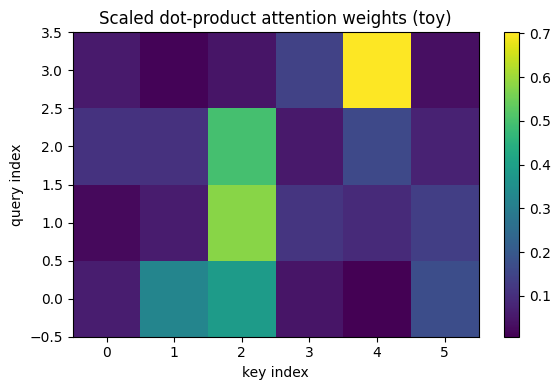

In [ ]:
# ====== Scaled Dot-Product Attention ======
class ScaledDotProductAttention(nn.Module):
    def __init__(self, dropout=0.0):
        super().__init__()
        self.drop = nn.Dropout(dropout)

    def forward(self, Q, K, V, mask=None):
        # Q: (B, nq, d), K,V: (B, nk, d)
        d = Q.size(-1)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d)  # (B, nq, nk)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        attn = F.softmax(scores, dim=-1)
        attn = self.drop(attn)
        out = torch.matmul(attn, V)  # (B, nq, d)
        return out, attn

attn = ScaledDotProductAttention().to(device)

# toy example
B, nq, nk, d = 1, 4, 6, 8
# B = batch size, nq = number of query, nk = number of key/val, d = embedding dimension
Q = torch.randn(B, nq, d, device=device)
K = torch.randn(B, nk, d, device=device)
V = torch.randn(B, nk, d, device=device)

out, w = attn(Q, K, V)
print("out shape:", out.shape, "attn shape:", w.shape)

plot_heatmap(w[0].detach().cpu().numpy(),
             xlab="key index", ylab="query index",
             title="Scaled dot-product attention weights (toy)")

This attention uses dot-product attention: score (q, k) = q . k / sq(d)

X axis: key index (0 -> 6)

Y axis: query index (0 -> 4)

Color: Attention weight value attn[i, j]

Brighter color -> Big weight -> Query cares more about that key

Darker color -> Small weight -> Query cares less about that key

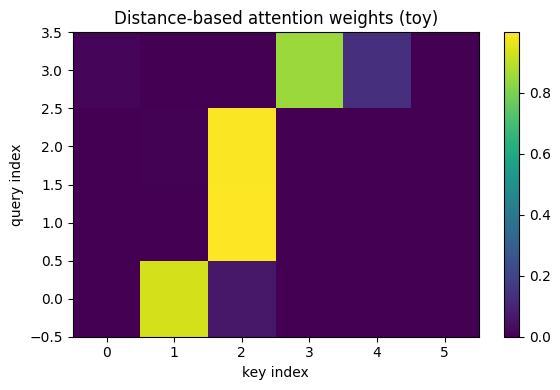

In [ ]:
# ====== Distance-based attention ======
class DistanceAttention(nn.Module):
    def __init__(self, dropout=0.0):
        super().__init__()
        self.drop = nn.Dropout(dropout)

    def forward(self, Q, K, V, mask=None):
        # score = -||q-k||^2 (efficient via norms)
        # Q: (B,nq,d), K: (B,nk,d)
        q2 = (Q**2).sum(dim=-1, keepdim=True)            # (B,nq,1)
        k2 = (K**2).sum(dim=-1).unsqueeze(1)             # (B,1,nk)
        # ||q-k||^2 = ||q||^2 + ||k||^2 - 2 q.k
        scores = -(q2 + k2 - 2*torch.matmul(Q, K.transpose(-2,-1)))
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        attn = F.softmax(scores, dim=-1)
        attn = self.drop(attn)
        out = torch.matmul(attn, V)
        return out, attn

dist_attn = DistanceAttention().to(device)
out2, w2 = dist_attn(Q, K, V)
plot_heatmap(w2[0].detach().cpu().numpy(),
             xlab="key index", ylab="query index",
             title="Distance-based attention weights (toy)")

This attention use distance-based scoring: score (q, k) = - ||q-k||^2

Brighter color -> query and key is near each other in vector space -> Higher attention

And vice versa

In [ ]:
# ====== Data + Nadaraya-Watson Attention Regression ======
def make_reg_data(n=60):
    x = np.linspace(-3, 3, n)
    y = np.sin(x) + 0.5*np.random.randn(n)
    return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

x_train, y_train = make_reg_data(15)
x_test = torch.linspace(-3, 3, 200)
y_true = torch.sin(x_test)

x_train = x_train.to(device); y_train = y_train.to(device)
x_test = x_test.to(device); y_true = y_true.to(device)

class NWRegressor(nn.Module):
    def __init__(self, init_h=1.0):
        super().__init__()
        self.raw_h = nn.Parameter(torch.tensor([math.log(math.exp(init_h)-1)], device=device)) # inverse softplus-ish

    def h(self):
        return F.softplus(self.raw_h) + 1e-6  # ensure positive

    def forward(self, xq, xk, yv, leave_one_out=False):
        # xq: (nq,), xk: (nk,), yv: (nk,)
        # returns (nq,)
        nq, nk = xq.numel(), xk.numel()
        h = self.h()

        # pairwise distances (nq, nk)
        dist2 = (xq.view(-1,1) - xk.view(1,-1))**2
        scores = -dist2 / (2*h*h)

        if leave_one_out and nq == nk and torch.allclose(xq, xk):
            scores = scores.clone()
            scores.fill_diagonal_(-1e9)

        w = F.softmax(scores, dim=-1)  # (nq,nk)
        yhat = w @ yv.view(-1,1)
        return yhat.view(-1), w

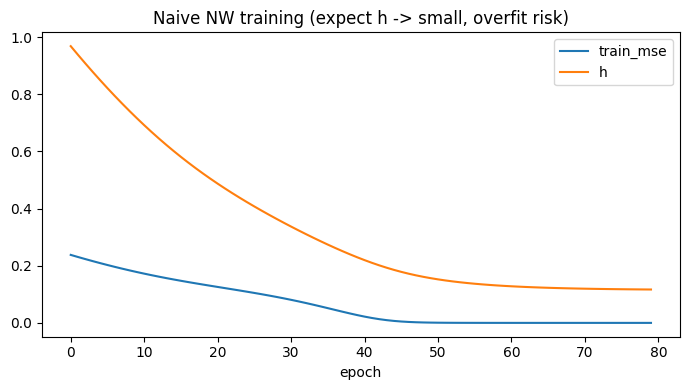

final h: 0.11684106290340424


In [ ]:
# ====== Train h (naive) ======
model_naive = NWRegressor(init_h=1.0).to(device)
opt = torch.optim.Adam(model_naive.parameters(), lr=0.05)

hist1 = {"train_mse": [], "h": []}
for epoch in range(80):
    model_naive.train()
    yhat, _ = model_naive(x_train, x_train, y_train, leave_one_out=False)
    loss = F.mse_loss(yhat, y_train)
    opt.zero_grad(); loss.backward(); opt.step()

    hist1["train_mse"].append(loss.item())
    hist1["h"].append(model_naive.h().item())

plot_curves(hist1, title="Naive NW training (expect h -> small, overfit risk)")
print("final h:", model_naive.h().item())

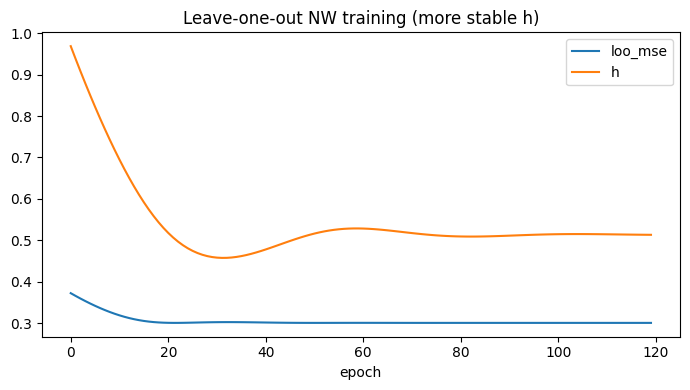

final h: 0.5133901238441467


In [ ]:
# ====== Train h (leave-one-out) ======
model_loo = NWRegressor(init_h=1.0).to(device)
opt = torch.optim.Adam(model_loo.parameters(), lr=0.05)

hist2 = {"loo_mse": [], "h": []}
for epoch in range(120):
    model_loo.train()
    yhat, _ = model_loo(x_train, x_train, y_train, leave_one_out=True)
    loss = F.mse_loss(yhat, y_train)
    opt.zero_grad(); loss.backward(); opt.step()

    hist2["loo_mse"].append(loss.item())
    hist2["h"].append(model_loo.h().item())

plot_curves(hist2, title="Leave-one-out NW training (more stable h)")
print("final h:", model_loo.h().item())

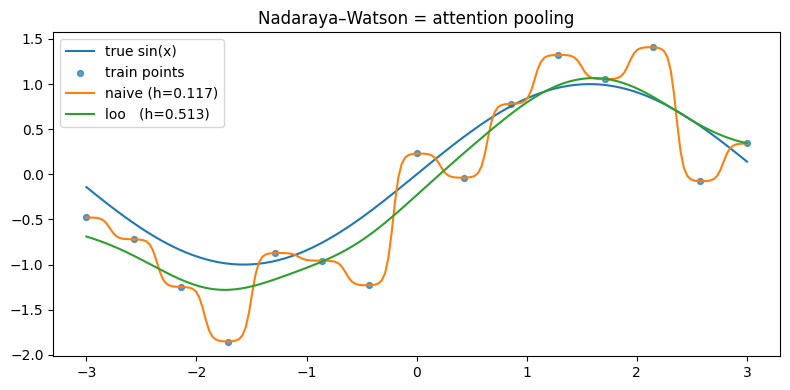

In [ ]:
# ====== Compare fitted curves ======
with torch.no_grad():
    yhat_naive, _ = model_naive(x_test, x_train, y_train, leave_one_out=False)
    yhat_loo, _   = model_loo(x_test, x_train, y_train, leave_one_out=False)

plt.figure(figsize=(8,4))
plt.plot(x_test.cpu(), y_true.cpu(), label="true sin(x)")
plt.scatter(x_train.cpu(), y_train.cpu(), s=18, label="train points", alpha=0.7)
plt.plot(x_test.cpu(), yhat_naive.cpu(), label=f"naive (h={model_naive.h().item():.3f})")
plt.plot(x_test.cpu(), yhat_loo.cpu(), label=f"loo   (h={model_loo.h().item():.3f})")
plt.legend(); plt.title("Nadaraya–Watson = attention pooling")
plt.tight_layout(); plt.show()

In [ ]:
# ====== Synthetic reverse dataset ======
PAD, BOS, EOS = 0, 1, 2
VOCAB_SIZE = 35  # tokens: 0..34 (0 pad,1 bos,2 eos, rest are content)

def gen_example(min_len=5, max_len=10):
    L = random.randint(min_len, max_len)
    seq = [random.randint(3, VOCAB_SIZE-1) for _ in range(L)]
    src = seq + [EOS]
    tgt = [BOS] + list(reversed(seq)) + [EOS]
    return src, tgt

class ReverseDataset(Dataset):
    def __init__(self, n=4000):
        self.data = [gen_example() for _ in range(n)]
    def __len__(self): return len(self.data)
    def __getitem__(self, i): return self.data[i]

def collate(batch):
    srcs, tgts = zip(*batch)
    max_s = max(len(s) for s in srcs)
    max_t = max(len(t) for t in tgts)
    src_pad = torch.full((len(batch), max_s), PAD, dtype=torch.long)
    tgt_pad = torch.full((len(batch), max_t), PAD, dtype=torch.long)
    src_len = torch.tensor([len(s) for s in srcs])
    tgt_len = torch.tensor([len(t) for t in tgts])
    for i,(s,t) in enumerate(zip(srcs,tgts)):
        src_pad[i,:len(s)] = torch.tensor(s)
        tgt_pad[i,:len(t)] = torch.tensor(t)
    return src_pad, src_len, tgt_pad, tgt_len

train_ds = ReverseDataset(5000)
test_ds  = ReverseDataset(800)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, collate_fn=collate)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False, collate_fn=collate)

In [ ]:
# ====== Additive (Bahdanau) Attention ======
class AdditiveAttention(nn.Module):
    def __init__(self, d_q, d_k, d_attn, dropout=0.1):
        super().__init__()
        self.Wq = nn.Linear(d_q, d_attn, bias=False)
        self.Wk = nn.Linear(d_k, d_attn, bias=False)
        self.v  = nn.Linear(d_attn, 1, bias=False)
        self.drop = nn.Dropout(dropout)

    def forward(self, q, K, mask):
        # q: (B, d_q) ; K: (B, T, d_k) ; mask: (B, T) 1 for valid
        # scores: (B, T)
        scores = self.v(torch.tanh(self.Wq(q).unsqueeze(1) + self.Wk(K))).squeeze(-1)
        scores = scores.masked_fill(mask == 0, -1e9)
        w = F.softmax(scores, dim=-1)
        w = self.drop(w)
        context = torch.bmm(w.unsqueeze(1), K).squeeze(1)  # (B, d_k)
        return context, w

In [ ]:
# ====== Seq2Seq GRU + attention ======
class Encoder(nn.Module):
    def __init__(self, vocab_size, d_emb=64, d_hid=128):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, d_emb, padding_idx=PAD)
        self.rnn = nn.GRU(d_emb, d_hid, batch_first=True)
    def forward(self, src, src_len):
        x = self.emb(src)
        # pack for speed (optional, but keep simple)
        packed = nn.utils.rnn.pack_padded_sequence(x, src_len.cpu(), batch_first=True, enforce_sorted=False)
        out_packed, hT = self.rnn(packed)
        H, _ = nn.utils.rnn.pad_packed_sequence(out_packed, batch_first=True)  # (B, Ts, d_hid)
        return H, hT.squeeze(0)  # H (keys/values), last hidden as init

class Decoder(nn.Module):
    def __init__(self, vocab_size, d_emb=64, d_hid=128):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, d_emb, padding_idx=PAD)
        self.attn = AdditiveAttention(d_q=d_hid, d_k=d_hid, d_attn=128)
        self.rnn = nn.GRU(d_emb + d_hid, d_hid, batch_first=True)
        self.fc  = nn.Linear(d_hid, vocab_size)

    def forward(self, tgt, enc_H, enc_mask, h0):
        # tgt: (B, Tt) includes BOS..; teacher forcing
        B, Tt = tgt.shape
        logits = []
        attn_weights = []

        h = h0.unsqueeze(0)  # (1,B,d_hid)
        for t in range(Tt-1):
            yt = tgt[:, t]  # input token
            yemb = self.emb(yt)  # (B,d_emb)
            q = h.squeeze(0)     # (B,d_hid)
            ctx, w = self.attn(q, enc_H, enc_mask)  # ctx (B,d_hid), w (B,Ts)
            rnn_in = torch.cat([yemb, ctx], dim=-1).unsqueeze(1)  # (B,1,d_emb+d_hid)
            out, h = self.rnn(rnn_in, h)  # out (B,1,d_hid)
            logit = self.fc(out.squeeze(1))  # (B,vocab)
            logits.append(logit)
            attn_weights.append(w)

        logits = torch.stack(logits, dim=1)        # (B, Tt-1, vocab)
        attn_weights = torch.stack(attn_weights, dim=1)  # (B, Tt-1, Ts)
        return logits, attn_weights

class Seq2Seq(nn.Module):
    def __init__(self, vocab_size, d_emb=64, d_hid=128):
        super().__init__()
        self.enc = Encoder(vocab_size, d_emb, d_hid)
        self.dec = Decoder(vocab_size, d_emb, d_hid)

    def forward(self, src, src_len, tgt):
        enc_H, enc_last = self.enc(src, src_len)
        enc_mask = (src != PAD).to(src.device)  # (B,Ts)
        logits, attn_w = self.dec(tgt, enc_H, enc_mask, enc_last)
        return logits, attn_w

model = Seq2Seq(VOCAB_SIZE).to(device)

epoch 01 | train_loss 2.940 | test_loss 2.089 | test_acc 0.438
epoch 02 | train_loss 1.274 | test_loss 0.687 | test_acc 0.901
epoch 03 | train_loss 0.424 | test_loss 0.164 | test_acc 0.991
epoch 04 | train_loss 0.184 | test_loss 0.074 | test_acc 0.993
epoch 05 | train_loss 0.125 | test_loss 0.038 | test_acc 0.999
epoch 06 | train_loss 0.074 | test_loss 0.026 | test_acc 0.998
epoch 07 | train_loss 0.059 | test_loss 0.019 | test_acc 0.999
epoch 08 | train_loss 0.052 | test_loss 0.070 | test_acc 0.979
epoch 09 | train_loss 0.048 | test_loss 0.014 | test_acc 0.998
epoch 10 | train_loss 0.036 | test_loss 0.026 | test_acc 0.994
epoch 11 | train_loss 0.034 | test_loss 0.038 | test_acc 0.990
epoch 12 | train_loss 0.032 | test_loss 0.030 | test_acc 0.993


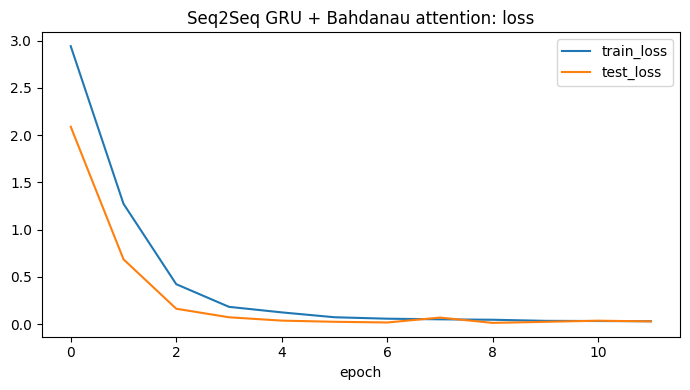

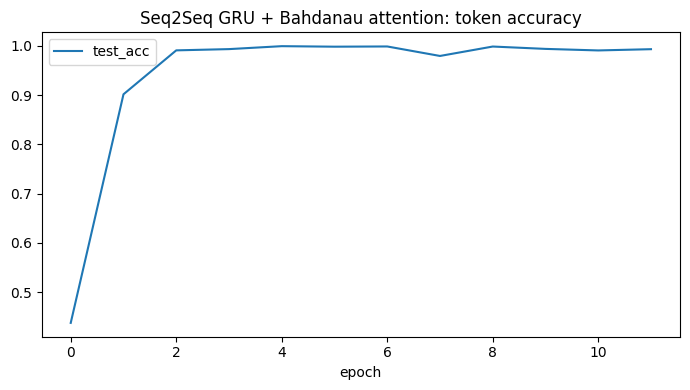

In [ ]:
# ====== Train loop ======
def seq_ce_loss(logits, tgt):
    # logits: (B,T,vocab) predicts tgt[:,1:]
    y = tgt[:, 1:].contiguous()
    loss = F.cross_entropy(logits.view(-1, logits.size(-1)),
                           y.view(-1),
                           ignore_index=PAD)
    return loss

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, total_tok, correct = 0.0, 0, 0
    for src, src_len, tgt, tgt_len in loader:
        src, src_len, tgt = src.to(device), src_len.to(device), tgt.to(device)
        logits, _ = model(src, src_len, tgt)
        loss = seq_ce_loss(logits, tgt)
        total_loss += loss.item() * src.size(0)

        pred = logits.argmax(-1)               # (B,T)
        gold = tgt[:,1:]
        mask = (gold != PAD)
        correct += ((pred == gold) & mask).sum().item()
        total_tok += mask.sum().item()

    return total_loss/len(loader.dataset), correct/total_tok

opt = torch.optim.Adam(model.parameters(), lr=1e-3)

history = {"train_loss": [], "test_loss": [], "test_acc": []}
for epoch in range(12):
    model.train()
    run_loss = 0.0
    for src, src_len, tgt, tgt_len in train_loader:
        src, src_len, tgt = src.to(device), src_len.to(device), tgt.to(device)
        logits, _ = model(src, src_len, tgt)
        loss = seq_ce_loss(logits, tgt)
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        run_loss += loss.item() * src.size(0)

    train_loss = run_loss/len(train_loader.dataset)
    test_loss, test_acc = evaluate(model, test_loader)
    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)
    print(f"epoch {epoch+1:02d} | train_loss {train_loss:.3f} | test_loss {test_loss:.3f} | test_acc {test_acc:.3f}")

plot_curves({"train_loss": history["train_loss"], "test_loss": history["test_loss"]},
            title="Seq2Seq GRU + Bahdanau attention: loss")
plot_curves({"test_acc": history["test_acc"]},
            title="Seq2Seq GRU + Bahdanau attention: token accuracy")

SRC: [33, 14, 14, 12, 23, 20, 9, 27, 8, 2]
TGT: [1, 8, 27, 9, 20, 23, 12, 14, 14, 33, 2]
PRD: [1, 8, 27, 9, 20, 23, 12, 14, 14, 33, 2]


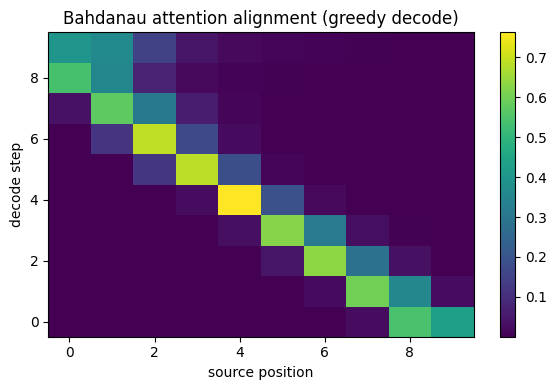

In [ ]:
# ====== Visualize attention map ======
@torch.no_grad()
def greedy_decode_with_attention(model, src):
    model.eval()
    src = src.unsqueeze(0).to(device)
    src_len = torch.tensor([src.size(1)], device=device)

    enc_H, enc_last = model.enc(src, src_len)
    enc_mask = (src != PAD)

    # start with BOS
    ys = [BOS]
    h = enc_last.unsqueeze(0)
    attn_maps = []
    for _ in range(20):
        yt = torch.tensor([ys[-1]], device=device)
        yemb = model.dec.emb(yt)
        q = h.squeeze(0)
        ctx, w = model.dec.attn(q, enc_H, enc_mask.squeeze(0))
        rnn_in = torch.cat([yemb, ctx], dim=-1).unsqueeze(1)
        out, h = model.dec.rnn(rnn_in, h)
        logit = model.dec.fc(out.squeeze(1))
        nxt = int(logit.argmax(-1).item())
        ys.append(nxt)
        attn_maps.append(w.squeeze(0).cpu().numpy())
        if nxt == EOS: break
    return ys, np.stack(attn_maps, axis=0)

# take 1 example from test set
src_ex, tgt_ex = test_ds[0]
src_tensor = torch.tensor(src_ex, dtype=torch.long)

pred_tokens, attn_map = greedy_decode_with_attention(model, src_tensor)

print("SRC:", src_ex)
print("TGT:", tgt_ex)
print("PRD:", pred_tokens)

# attn_map shape: (T_pred, T_src)
plot_heatmap(attn_map,
             xlab="source position", ylab="decode step",
             title="Bahdanau attention alignment (greedy decode)")

In [ ]:
# ====== Summary table ======
summary = pd.DataFrame([{
    "model": "GRU + Bahdanau attention",
    "test_loss": history["test_loss"][-1],
    "test_token_acc": history["test_acc"][-1],
    "notes": "Synthetic reverse task"
}])
summary

,model,test_loss,test_token_acc,notes
0,GRU + Bahdanau attention,0.030349,0.992982,Synthetic reverse task
